In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import matplotlib.pyplot as plt


In [24]:
df = pd.read_csv("../data/Medical_appointment_data.csv")


In [25]:
# Target encoding
df["no_show"] = df["no_show"].map({"yes":1, "no":0})
y = df["no_show"]
X = df.drop(columns=["no_show"])


In [26]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [27]:
# --- Load preprocessor ---
preprocessor = joblib.load("models/preprocessor_cat.pkl")

In [28]:
# --- Define Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        random_state=42, use_label_encoder=False, eval_metric="logloss"
    )
}


In [29]:


# --- Training & Evaluation ---
results = {}
for name, model in models.items():
    # Pipeline with SMOTE for imbalance handling
    clf = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:,1]

    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results[name] = {"F1": f1, "ROC-AUC": roc, "Precision": precision, "Recall": recall}

    print(f"\n{name} Results:")
    print(f"F1: {f1:.3f}, ROC-AUC: {roc:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")



Logistic Regression Results:
F1: 0.564, ROC-AUC: 0.725, Precision: 0.512, Recall: 0.628

Random Forest Results:
F1: 0.471, ROC-AUC: 0.664, Precision: 0.551, Recall: 0.411


C:\Users\cxsha\PycharmProjects\medical_appt_noshowpredict_demandforecasting\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
F1: 0.580, ROC-AUC: 0.740, Precision: 0.439, Recall: 0.857


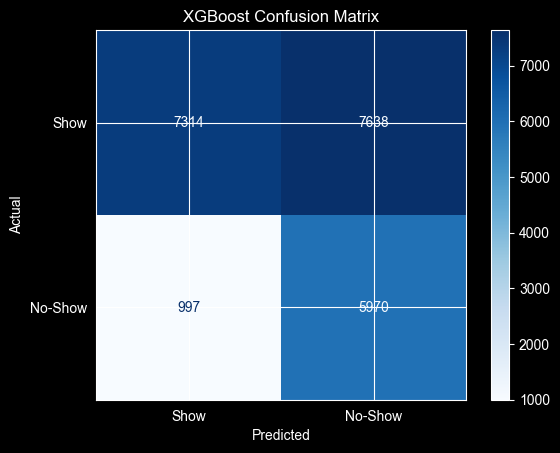

In [31]:
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Show","No-Show"])
    disp.plot(cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [32]:
# --- Compare Models ---
results_df = pd.DataFrame(results).T
print("\nModel Comparison:\n", results_df)



Model Comparison:
                            F1   ROC-AUC  Precision    Recall
Logistic Regression  0.563729  0.724858   0.511704  0.627530
Random Forest        0.471188  0.663893   0.551366  0.411368
XGBoost              0.580316  0.739709   0.438713  0.856897


In [33]:
# --- Save Best Model ---
best_model_name = results_df.sort_values(by="F1", ascending=False).index[0]
print(f"\nBest model selected: {best_model_name}")

best_model = models[best_model_name]
final_clf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", best_model)
])
final_clf.fit(X_train, y_train)

joblib.dump(final_clf, "../models/no_show_model.pkl")
print("Best model saved to ../models/no_show_model.pkl")



Best model selected: XGBoost


C:\Users\cxsha\PycharmProjects\medical_appt_noshowpredict_demandforecasting\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:14:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best model saved to ../models/no_show_model.pkl
